# Tesis: Agricultura de Precisión con Imágenes Satelitales

**Objetivo**: Desarrollar y validar un pipeline de análisis de cultivos de arroz con Sentinel‑2 y modelos de IA, comenzando con datos sintéticos (100 t totales en parcelas 10×10) y evolucionando hacia datos reales.

---

## Resumen Metodológico (Cap. III)

1. **3.3 Técnicas e instrumentos**  
   - Preprocesamiento: recorte, calibración, máscara NDVI.  
   - Cálculo de índices espectrales (NDVI, EVI, SAVI).

2. **3.4 Procedimiento**  
   - **Segmentación**: máscara agrícola, train/val/test.  
   - **Clasificación**: prototipo U‑Net ligero (maqueta).

3. **3.5 Plan de análisis**  
   - Métricas: Accuracy, IoU, Dice.  
   - Validación con datos sintéticos (ground‑truth artificial).

---

## Definir Datos Sintéticos Normalizados

Crearemos 2 parcelas artificiales de 10×10 celdas con NDVI y producción total = 100 t.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, Point

In [2]:
# Parámetros de la parcela
n = 10   # 10×10 celdas
total_t = 100.0  # toneladas totales

# Crear grid de coordenadas 0..9 en X y Y
xs, ys = np.meshgrid(range(n), range(n))
coords = np.vstack([xs.ravel(), ys.ravel()]).T  # (100,2)

# Simular NDVI con pico en el centro (distribución gaussiana)
cx, cy = (n-1)/2, (n-1)/2
sigma = 3.0
ndvi = np.exp(-(((coords[:,0]-cx)**2 + (coords[:,1]-cy)**2)/(2*sigma**2)))

# Normalizar NDVI de 0 a 1
ndvi = (ndvi - ndvi.min()) / (ndvi.max() - ndvi.min())

# Distribuir la producción total según NDVI
produccion = ndvi / ndvi.sum() * total_t

# Crear DataFrame para visualizar
df = pd.DataFrame({
    'x': coords[:,0],
    'y': coords[:,1],
    'ndvi': ndvi,
    'produccion_t': produccion
})

df.head()

,x,y,ndvi,produccion_t
0,0,0,0.000000,0.000000
1,1,0,0.068016,0.164426
2,2,0,0.143006,0.345711
3,3,0,0.208838,0.504856
4,4,0,0.247664,0.598715


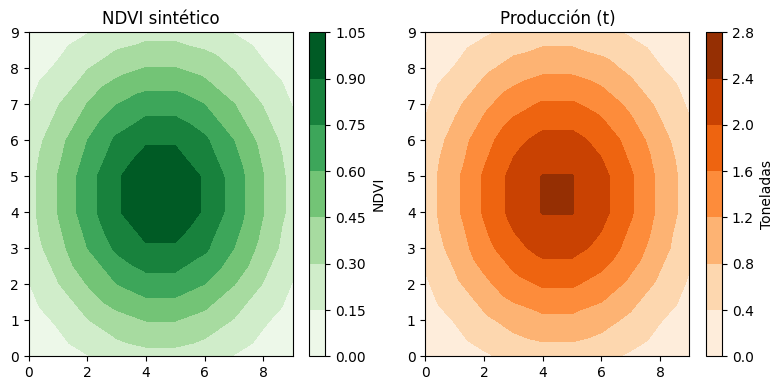

In [3]:
# Plot NDVI y producción en mapa de calor 2D
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("NDVI sintético")
plt.tricontourf(df['x'], df['y'], df['ndvi'], cmap='Greens')
plt.colorbar(label='NDVI')

plt.subplot(1,2,2)
plt.title("Producción (t)")
plt.tricontourf(df['x'], df['y'], df['produccion_t'], cmap='Oranges')
plt.colorbar(label='Toneladas')

plt.tight_layout()
plt.show()